In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller

In [13]:
df_a = yf.download('MA', start = '2020-01-01', end = '2025-01-01')['Close']['MA']
df_b = yf.download('V', start = '2020-01-01', end = '2025-01-01')['Close']['V']


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [14]:
X = sm.add_constant(df_b)

model = sm.OLS(df_a, X).fit()
beta = model.params.iloc[1]

print("Hedge Ratio:", beta)

Hedge Ratio: 1.8277176199432046


In [15]:
spread = df_a - beta*df_b

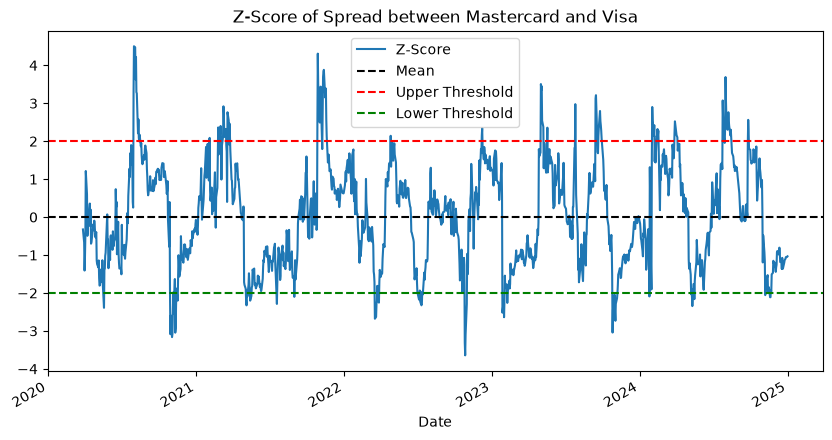

In [16]:
window = 60
rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()
z_score = (spread - rolling_mean) / rolling_std

z_score.plot(figsize = (10,5), title = "Z-Score of Spread between Mastercard and Visa")
plt.axhline(0, color = 'black', linestyle = '--')
plt.axhline(2,color = 'red', linestyle = '--')
plt.axhline(-2,color = 'green', linestyle = '--')
plt.legend(['Z-Score', 'Mean', 'Upper Threshold', 'Lower Threshold'])
plt.show()

positions = []
for z in z_score:
    if z > 2:
        positions.append(-1)  # Short position
    elif z < -2:
        positions.append(1)   # Long position
    else:
        positions.append(0)   # No position
positions_series = pd.Series(positions, index=z_score.index)


C:\Users\devon\AppData\Local\Temp\ipykernel_7572\2528416623.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


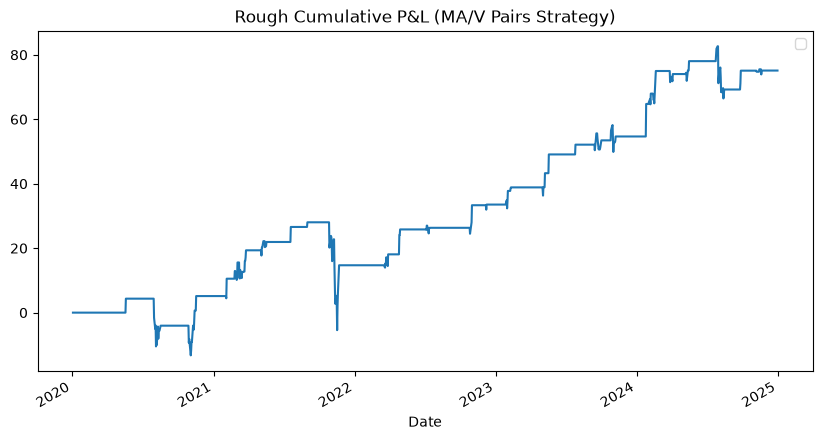

In [17]:
spread_change = spread.diff()
strategy_returns = positions_series.shift(1) * spread_change
strategy_returns.head(20)
cumulative_pnl = strategy_returns.cumsum()
cumulative_pnl.plot(figsize=(10,5), title="Rough Cumulative P&L (MA/V Pairs Strategy)")
plt.legend()
plt.show()